In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_79.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_123.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_266.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_203.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_18.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_259.h5
/kaggle/input/datasets/tthien/shangh

In [2]:
!git clone https://github.com/arzoovaswani415/Crowd_density_estimation.git

fatal: destination path 'Crowd_density_estimation' already exists and is not an empty directory.


In [3]:
import sys
sys.path.append("/kaggle/working/Crowd_density_estimation")

from src.dataset import ShanghaiTechDataset
from src.csrnet_deform_attention import CSRNetDeformAttention

In [4]:
train_img_dir = "/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/ShanghaiTech/part_B/train_data/images"
train_gt_dir  = "/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/ShanghaiTech/part_B/train_data/ground-truth-h5"

test_img_dir = "/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/ShanghaiTech/part_B/test_data/images"
test_gt_dir  = "/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/ShanghaiTech/part_B/test_data/ground-truth-h5"

In [5]:
from torch.utils.data import DataLoader

train_dataset = ShanghaiTechDataset(train_img_dir, train_gt_dir, resize=(256,256))
test_dataset  = ShanghaiTechDataset(test_img_dir, test_gt_dir, resize=(256,256))

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

Total valid samples: 400
Total valid samples: 316


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CSRNetDeformAttention().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 236MB/s] 


In [7]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, density_maps in train_loader:
        images = images.to(device)
        density_maps = density_maps.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        scale = density_maps.shape[2] / outputs.shape[2]

        density_maps_resized = F.interpolate(
            density_maps,
            size=outputs.shape[2:],
            mode='bilinear',
            align_corners=False
        ) * (scale * scale)

        loss = criterion(outputs, density_maps_resized)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.6f}")

Epoch [1/20] Loss: 0.372566
Epoch [2/20] Loss: 0.322557
Epoch [3/20] Loss: 0.304958
Epoch [4/20] Loss: 0.289245
Epoch [5/20] Loss: 0.274175
Epoch [6/20] Loss: 0.262694
Epoch [7/20] Loss: 0.245203
Epoch [8/20] Loss: 0.239072
Epoch [9/20] Loss: 0.228460
Epoch [10/20] Loss: 0.223772
Epoch [11/20] Loss: 0.220410
Epoch [12/20] Loss: 0.229357
Epoch [13/20] Loss: 0.196524
Epoch [14/20] Loss: 0.180824
Epoch [15/20] Loss: 0.179499
Epoch [16/20] Loss: 0.170110
Epoch [17/20] Loss: 0.168658
Epoch [18/20] Loss: 0.153461
Epoch [19/20] Loss: 0.156575
Epoch [20/20] Loss: 0.154835


In [11]:
for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-6

print("LR reduced to:", optimizer.param_groups[0]['lr'])

LR reduced to: 1e-06


In [12]:
for epoch in range(20, 50):
    model.train()
    epoch_loss = 0

    for images, density_maps in train_loader:
        images = images.to(device)
        density_maps = density_maps.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        scale = density_maps.shape[2] / outputs.shape[2]

        density_maps_resized = F.interpolate(
            density_maps,
            size=outputs.shape[2:],
            mode='bilinear',
            align_corners=False
        ) * (scale * scale)

        loss = criterion(outputs, density_maps_resized)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    print(f"Epoch [{epoch+1}/50] Loss: {epoch_loss:.6f}")

Epoch [21/50] Loss: 0.126722
Epoch [22/50] Loss: 0.119238
Epoch [23/50] Loss: 0.115532
Epoch [24/50] Loss: 0.112609
Epoch [25/50] Loss: 0.109724
Epoch [26/50] Loss: 0.107420
Epoch [27/50] Loss: 0.104934
Epoch [28/50] Loss: 0.103245
Epoch [29/50] Loss: 0.101177
Epoch [30/50] Loss: 0.099153
Epoch [31/50] Loss: 0.097514
Epoch [32/50] Loss: 0.095985
Epoch [33/50] Loss: 0.094651
Epoch [34/50] Loss: 0.093605
Epoch [35/50] Loss: 0.091799
Epoch [36/50] Loss: 0.090391
Epoch [37/50] Loss: 0.089875
Epoch [38/50] Loss: 0.088287
Epoch [39/50] Loss: 0.087096
Epoch [40/50] Loss: 0.086190
Epoch [41/50] Loss: 0.085360
Epoch [42/50] Loss: 0.084323
Epoch [43/50] Loss: 0.082898
Epoch [44/50] Loss: 0.082633
Epoch [45/50] Loss: 0.081370
Epoch [46/50] Loss: 0.080509
Epoch [47/50] Loss: 0.079349
Epoch [48/50] Loss: 0.078449
Epoch [49/50] Loss: 0.077914
Epoch [50/50] Loss: 0.077463


In [13]:
model.eval()
mae = 0.0

with torch.no_grad():
    for images, density_maps in test_loader:
        images = images.to(device)
        density_maps = density_maps.to(device)

        outputs = model(images)

        scale = density_maps.shape[2] / outputs.shape[2]

        density_maps_resized = F.interpolate(
            density_maps,
            size=outputs.shape[2:],
            mode='bilinear',
            align_corners=False
        ) * (scale * scale)

        pred_count = outputs.sum().item()
        gt_count = density_maps_resized.sum().item()

        mae += abs(pred_count - gt_count)

mae /= len(test_loader)
print("CSRNet + Deformable Attention MAE:", mae)

CSRNet + Deformable Attention MAE: 20.6103868907011


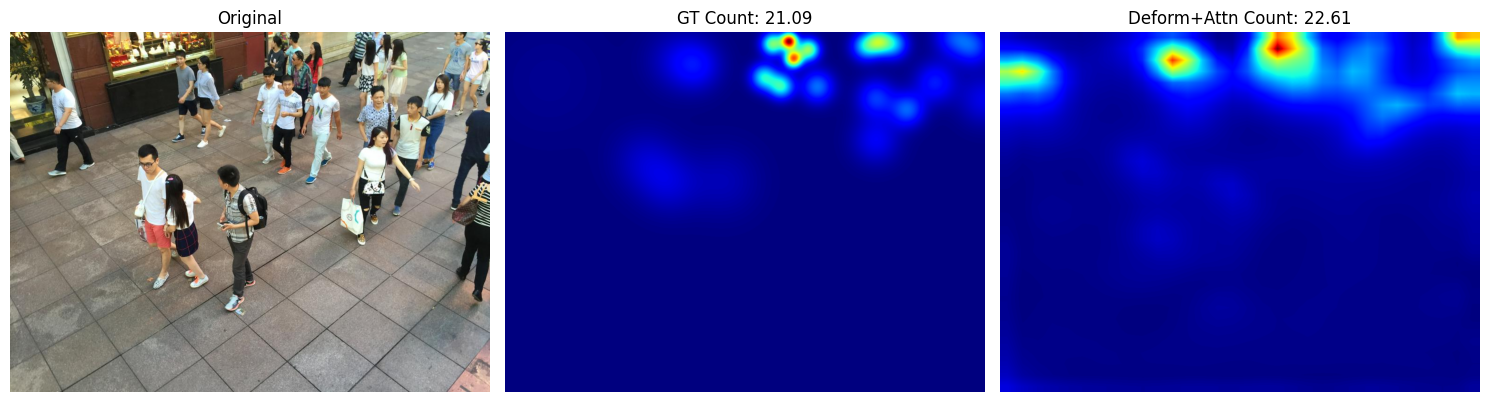

In [14]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
model.eval()

img_files = sorted(os.listdir(test_img_dir))
idx = 0
img_name = img_files[idx]

img_path = os.path.join(test_img_dir, img_name)
h5_path  = os.path.join(test_gt_dir, img_name.replace(".jpg", ".h5"))

img = Image.open(img_path).convert("RGB")
img_np = np.array(img)

with h5py.File(h5_path, 'r') as f:
    gt_density = np.array(f["density"])

gt_count = gt_density.sum()

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
])

input_img = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_img)

pred_count = output.sum().item()

pred_upsampled = F.interpolate(
    output,
    size=gt_density.shape,
    mode='bilinear',
    align_corners=False
).squeeze().cpu().numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gt_density, cmap="jet")
plt.title(f"GT Count: {gt_count:.2f}")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_upsampled, cmap="jet")
plt.title(f"Deform+Attn Count: {pred_count:.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()